# Eksperimen Machine Learning
## Prediksi Customer Churn Menggunakan IBM Telco Customer Churn Dataset

**Nama:** La Ode Alvin Rahmat Saputra

### Tujuan
Notebook ini bertujuan melakukan eksplorasi data dan preprocessing terhadap dataset IBM Telco Customer Churn sebagai tahap awal pembangunan model machine learning. Hasil preprocessing pada notebook ini akan digunakan sebagai dasar pembuatan pipeline preprocessing otomatis pada tahap selanjutnya.

# 1. Business Understanding

## Latar Belakang

Customer churn merupakan kondisi ketika pelanggan berhenti menggunakan layanan suatu perusahaan. Tingginya tingkat churn dapat menyebabkan penurunan pendapatan serta meningkatnya biaya untuk memperoleh pelanggan baru. Oleh karena itu, perusahaan perlu mengidentifikasi pelanggan yang berpotensi melakukan churn sehingga strategi retensi dapat dilakukan lebih awal.

## Permasalahan

Bagaimana membangun dataset yang siap digunakan untuk melatih model machine learning yang mampu memprediksi kemungkinan pelanggan melakukan churn?

## Tujuan

Melakukan proses eksplorasi data (EDA) dan preprocessing sehingga menghasilkan dataset yang bersih, konsisten, dan siap digunakan pada proses pelatihan model machine learning.

In [1]:
# =====================================================
# Import Library
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
# =====================================================
# Data Loading
# =====================================================

df = pd.read_csv("../raw_dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Ukuran Dataset :", df.shape)

df.head()

Ukuran Dataset : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Data Understanding

Pada tahap ini dilakukan pemahaman awal terhadap dataset untuk mengetahui struktur data, tipe data, kualitas data, serta potensi permasalahan yang perlu ditangani sebelum proses preprocessing dilakukan.

In [3]:
# =====================================================
# Dataset Information
# =====================================================

print(f"Jumlah Baris  : {df.shape[0]}")
print(f"Jumlah Kolom  : {df.shape[1]}")

df.info()

Jumlah Baris  : 7043
Jumlah Kolom  : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pa

In [4]:
# =====================================================
# Statistical Summary
# =====================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# =====================================================
# Missing Values
# =====================================================

missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [6]:
# =====================================================
# Empty String Check
# =====================================================

(df == "").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# =====================================================
# Duplicate Data
# =====================================================

print("Jumlah data duplikat :", df.duplicated().sum())

Jumlah data duplikat : 0


In [8]:
# =====================================================
# Target Distribution
# =====================================================

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [10]:
df["TotalCharges"].describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [11]:
# Persentase target

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# 3. Exploratory Data Analysis (EDA)

Tahap Exploratory Data Analysis (EDA) bertujuan untuk memahami karakteristik dataset melalui visualisasi sehingga dapat ditemukan pola, hubungan antar variabel, maupun potensi permasalahan sebelum dilakukan preprocessing.

<Axes: xlabel='Churn', ylabel='count'>

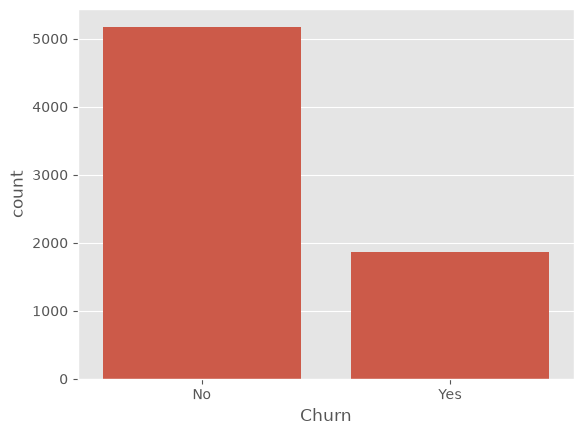

In [12]:
sns.countplot(data=df, x="Churn")

In [13]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

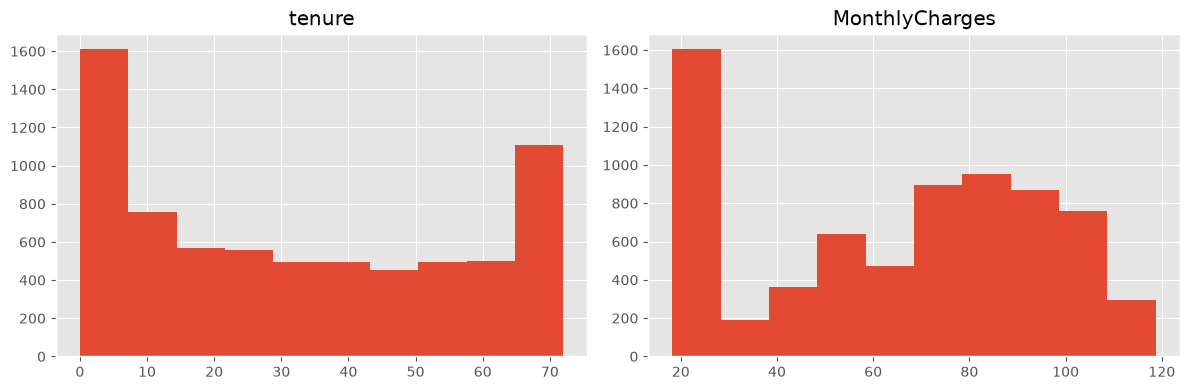

In [14]:
numerical = ["tenure","MonthlyCharges","TotalCharges"]

df[numerical].hist(figsize=(12,4))
plt.tight_layout()

<Axes: xlabel='Contract', ylabel='count'>

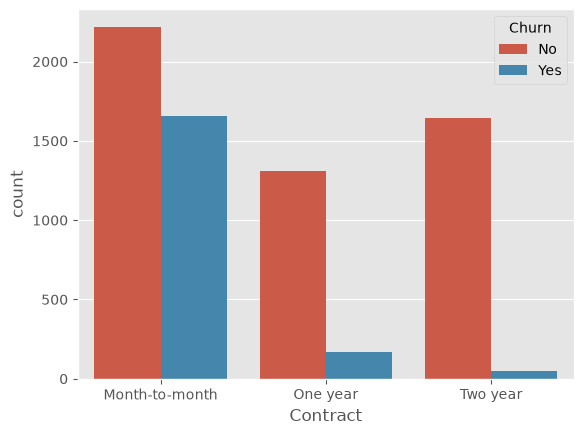

In [15]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

# 4. Data Preprocessing

Tahap preprocessing dilakukan untuk membersihkan dan mentransformasikan data sehingga siap digunakan dalam proses pelatihan model machine learning.

In [18]:
# Menghapus kolom identifier

df = df.drop(columns=["customerID"])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
# Mengubah TotalCharges menjadi numerik

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df = df.dropna(subset=["TotalCharges"])

df["TotalCharges"].isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [25]:
# Encode target

df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})
df["Churn"].value_counts()

Series([], Name: count, dtype: int64)

In [26]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [27]:
categorical_columns = X.select_dtypes(include="object").columns.tolist()

numerical_columns = X.select_dtypes(exclude="object").columns.tolist()

print(categorical_columns)

print(numerical_columns)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [28]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [29]:
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(
    X[numerical_columns]
)

In [30]:
processed_df = X.copy()

processed_df["Churn"] = y

processed_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-0.440327,-1.280248,-1.161694,-0.994194,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,NaN
1,-0.440327,0.064303,-0.260878,-0.173740,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,NaN
2,-0.440327,-1.239504,-0.363923,-0.959649,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,NaN
3,-0.440327,0.512486,-0.747850,-0.195248,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,NaN
4,-0.440327,-1.239504,0.196178,-0.940457,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,NaN


In [31]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   float64
 1   tenure                                 7032 non-null   float64
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetS

In [32]:
processed_df.to_csv(
    "telco_preprocessed.csv",
    index=False
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.


# Kesimpulan

Eksperimen telah berhasil dilakukan mulai dari data loading, data understanding, exploratory data analysis, hingga preprocessing. Dataset hasil preprocessing telah berhasil dihasilkan dalam format CSV sehingga siap digunakan pada tahap pembangunan model machine learning dan otomatisasi preprocessing pada kriteria berikutnya.